# Demo: Reverse Diffusion Sampling and Image Generation
## Creating Images from Pure Noise with Fashion MNIST

In this demo, we'll explore the complete reverse diffusion sampling process. Starting from pure Gaussian noise, we'll progressively denoise to create coherent  MNIST images.

**What You'll Learn:**
- How the reverse diffusion process works step by step
- Generating images from a trained diffusion model
- Visualizing the denoising trajectory from noise → digit



## Section 1: Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torchvision
from torchvision import transforms, datasets
import math
from pathlib import Path
import sys

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(" Imports complete")


Using device: cuda
 Imports complete


## Section 2: Rebuild Model Architecture 

We need to define the **exact same** U-Net architecture that was used during training so the saved weights can be loaded correctly.

In [2]:
class TimeEmbedding(nn.Module):
    """Sinusoidal time embedding for timestep conditioning."""

    def __init__(self, embedding_dim=128):
        super().__init__()
        self.embedding_dim = embedding_dim

    def forward(self, timestep):
        device = timestep.device
        half_dim = self.embedding_dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half_dim, device=device) / half_dim
        )
        args = timestep[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ResidualBlock(nn.Module):
    """Residual block with timestep conditioning."""

    def __init__(self, in_channels, out_channels, time_embedding_dim=128):
        super().__init__()
        self.norm1 = nn.GroupNorm(num_groups=32, num_channels=in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(num_groups=32, num_channels=out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_embedding_dim, out_channels),
            nn.SiLU(),
            nn.Linear(out_channels, out_channels),
        )
        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, time_embedding):
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)
        time_scale_shift = self.time_mlp(time_embedding)[:, :, None, None]
        h = h * time_scale_shift
        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)
        return h + self.skip(x)


class SimpleUNet(nn.Module):
    """Simple U-Net for MNIST noise prediction."""

    def __init__(self, image_channels=1, base_channels=64, time_embedding_dim=128):
        super().__init__()
        self.time_embedding = TimeEmbedding(time_embedding_dim)
        self.init_conv = nn.Conv2d(
            image_channels, base_channels, kernel_size=3, padding=1
        )

        # Encoder — forward order: downsample conv → res block
        self.down_conv1 = nn.Conv2d(
            base_channels, base_channels, kernel_size=4, stride=2, padding=1
        )
        self.down_res1 = ResidualBlock(
            base_channels, base_channels * 2, time_embedding_dim
        )

        self.down_conv2 = nn.Conv2d(
            base_channels * 2, base_channels * 2, kernel_size=4, stride=2, padding=1
        )
        self.down_res2 = ResidualBlock(
            base_channels * 2, base_channels * 2, time_embedding_dim
        )

        # Middle
        self.middle_res = ResidualBlock(
            base_channels * 2, base_channels * 2, time_embedding_dim
        )

        # Decoder
        self.up_conv2 = nn.ConvTranspose2d(
            base_channels * 2, base_channels * 2, kernel_size=4, stride=2, padding=1
        )
        self.up_res2 = ResidualBlock(
            base_channels * 2, base_channels, time_embedding_dim
        )

        self.up_conv1 = nn.ConvTranspose2d(
            base_channels, base_channels, kernel_size=4, stride=2, padding=1
        )
        self.up_res1 = ResidualBlock(base_channels, base_channels, time_embedding_dim)

        # Final output
        self.final_norm = nn.GroupNorm(num_groups=32, num_channels=base_channels)
        self.final_conv = nn.Conv2d(
            base_channels, image_channels, kernel_size=3, padding=1
        )

    def forward(self, x, timestep):
        time_emb = self.time_embedding(timestep)
        h = self.init_conv(x)

        # Encoder: downsample → res block
        h = self.down_conv1(h)
        h = self.down_res1(h, time_emb)

        h = self.down_conv2(h)
        h = self.down_res2(h, time_emb)

        # Middle
        h = self.middle_res(h, time_emb)

        # Decoder: upsample → res block
        h = self.up_conv2(h)
        h = self.up_res2(h, time_emb)

        h = self.up_conv1(h)
        h = self.up_res1(h, time_emb)

        # Final output
        h = self.final_norm(h)
        h = F.silu(h)
        h = self.final_conv(h)
        return h


print(f" Model architecture defined")



 Model architecture defined


## Section 3: Load Trained Checkpoint from previous lesson

In [3]:
# Rebuild the noise schedule (must match training)
num_timesteps = 1000
betas = torch.linspace(0.0001, 0.02, num_timesteps)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.ones(1), alphas_cumprod[:-1]])

# Load trained model
model = SimpleUNet(image_channels=1, base_channels=64, time_embedding_dim=128).to(
    device
)

checkpoint_path = Path("../../model_checkpoints/diffusion_model_lesson16.pt")
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

epochs_trained = checkpoint.get("epoch", "?")
print(f"✓ Loaded model trained for {epochs_trained} epochs")
print(f"  From: {checkpoint_path.resolve()}")

/tmp/ipykernel_12516/963416108.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


✓ Loaded model trained for 10 epochs
  From: /workspace/cd1823-building-genai/model_checkpoints/diffusion_model_lesson16.pt


## Section 4: Implement DDPM Reverse Sampling

The reverse process starts from pure noise $x_T \sim \mathcal{N}(0, I)$ and iteratively denoises:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}} \cdot \epsilon_\theta(x_t, t) \right) + \sigma_t \cdot z$$

Where:
- $\epsilon_\theta(x_t, t)$: The noise predicted by our trained U-Net
- $\sigma_t = \sqrt{\tilde{\beta}_t}$: Posterior standard deviation
- $z \sim \mathcal{N}(0, I)$: Fresh random noise (except at $t = 0$)

In [21]:
@torch.no_grad()
def sample_ddpm(model, num_samples=16):
    """Generate images via reverse diffusion: x_T → x_0."""
    model.eval()
    x = torch.randn(num_samples, 1, 28, 28, device=device)  # Start from pure noise

    for t_idx in range(num_timesteps - 1, -1, -1):
        t = torch.full((num_samples,), t_idx, dtype=torch.long, device=device)

        # U-Net predicts the noise that was added
        pred_noise = model(x, t)

        # Reverse step coefficients
        alpha = alphas[t_idx]
        alpha_cum = alphas_cumprod[t_idx]
        alpha_cum_prev = alphas_cumprod_prev[t_idx]

        # Posterior variance: β̃_t = (1 - ᾱ_{t-1}) / (1 - ᾱ_t) * β_t
        posterior_var = (1 - alpha_cum_prev) / (1 - alpha_cum) * (1 - alpha)

        # Predicted mean: μ = (x_t - (1-α_t)/√(1-ᾱ_t) * ε_pred) / √α_t
        x = (x - (1 - alpha) / torch.sqrt(1 - alpha_cum) * pred_noise) / torch.sqrt(
            alpha
        )

        # Add noise for all steps except the last one (t=0)
        if t_idx > 0:
            x = x + torch.sqrt(posterior_var) * torch.randn_like(x)

    return torch.clamp(x, -1.0, 1.0)


print("✓ Sampling function defined")


✓ Sampling function defined


## Section 5: Generate Samples

Now we run the full 1000-step reverse process to generate MNIST digits from pure noise.

Generating 16 samples (1000 reverse steps)... this may take a few minutes


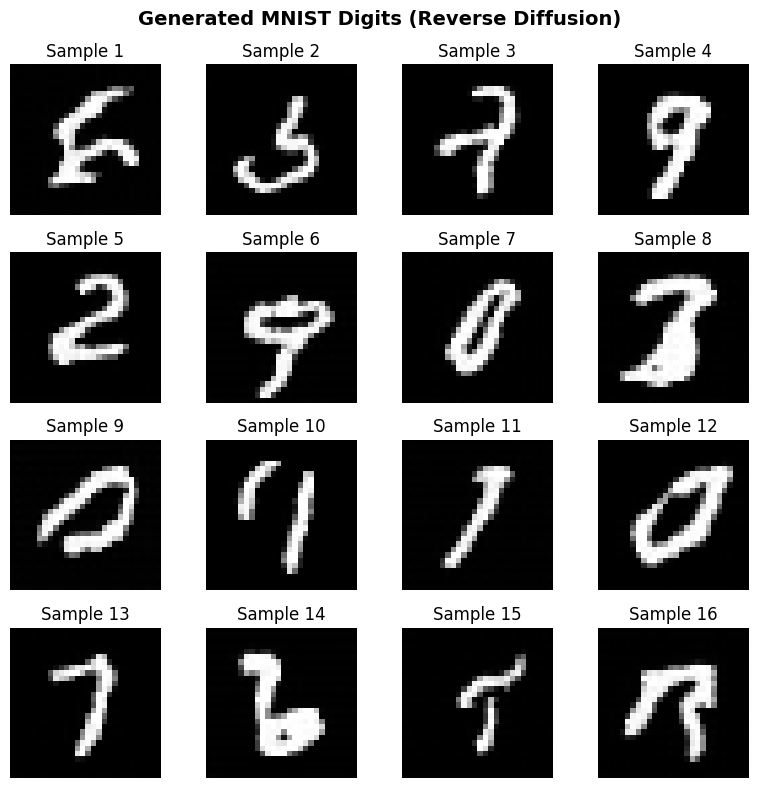

Sample range: [-1.000, 1.000]


In [27]:
print("Generating 16 samples (1000 reverse steps)... this may take a few minutes")
samples = sample_ddpm(model, num_samples=16)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for idx, ax in enumerate(axes.flat):
    ax.imshow(samples[idx, 0].cpu().numpy(), cmap="gray")
    ax.set_title(f"Sample {idx+1}")
    ax.axis("off")

plt.suptitle(
    "Generated MNIST Digits (Reverse Diffusion)", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

print(f"Sample range: [{samples.min():.3f}, {samples.max():.3f}]")

## Section 6: Visualize the Denoising Trajectory

Let's watch a single image emerge from noise by saving snapshots at key timesteps during the reverse process.

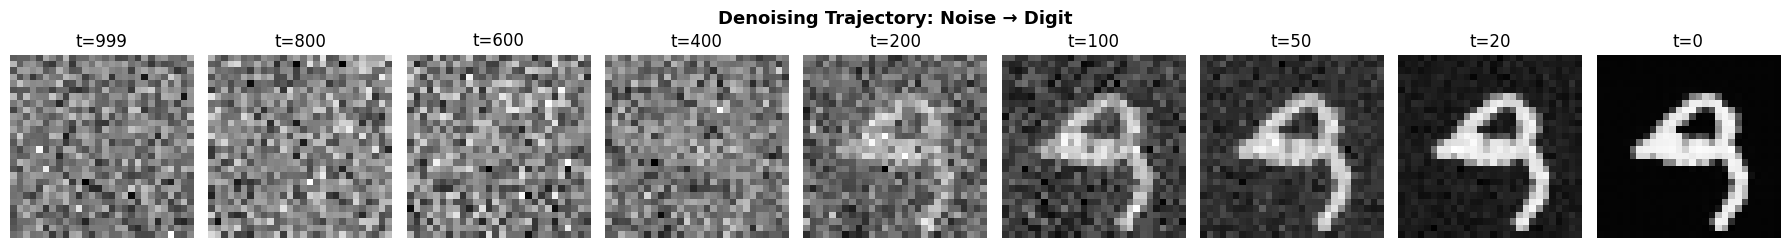

In [28]:
@torch.no_grad()
def sample_with_trajectory(model, snapshot_steps=None):
    """Generate one image and save snapshots at specified timesteps."""
    if snapshot_steps is None:
        snapshot_steps = [999, 800, 600, 400, 200, 100, 50, 20, 0]

    model.eval()
    x = torch.randn(1, 1, 28, 28, device=device)
    snapshots = {}

    for t_idx in range(num_timesteps - 1, -1, -1):
        t = torch.full((1,), t_idx, dtype=torch.long, device=device)
        pred_noise = model(x, t)

        alpha = alphas[t_idx]
        alpha_cum = alphas_cumprod[t_idx]
        alpha_cum_prev = alphas_cumprod_prev[t_idx]
        posterior_var = (1 - alpha_cum_prev) / (1 - alpha_cum) * (1 - alpha)

        x = (x - (1 - alpha) / torch.sqrt(1 - alpha_cum) * pred_noise) / torch.sqrt(
            alpha
        )
        if t_idx > 0:
            x = x + torch.sqrt(posterior_var) * torch.randn_like(x)

        if t_idx in snapshot_steps:
            snapshots[t_idx] = x.clone().cpu()

    return snapshots


# Run trajectory sampling
snapshots = sample_with_trajectory(model)

# Plot the denoising trajectory
steps = sorted(snapshots.keys(), reverse=True)
fig, axes = plt.subplots(1, len(steps), figsize=(2 * len(steps), 2.5))
for ax, t in zip(axes, steps):
    img = snapshots[t][0, 0].numpy()
    ax.imshow(img, cmap="gray")
    ax.set_title(f"t={t}")
    ax.axis("off")

plt.suptitle("Denoising Trajectory: Noise → Digit", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Summary

**What we did:**
1. Rebuilt the exact same U-Net architecture used during training (Lesson 16)
2. Loaded the saved checkpoint weights
3. Implemented the full DDPM reverse sampling loop (1000 steps)
4. Generated MNIST digits starting from pure Gaussian noise

**Key takeaways:**
- The reverse process iteratively removes predicted noise, one timestep at a time
- Image quality depends on how many epochs the model was trained for
- The same reverse process works for any class of images the model was trained on
- Diffusion models trade sampling speed (1000 steps!) for high-quality, diverse output